In [2]:
# FUENTES: https://github.com/rjrahul24/ga-reinforcement-learning-image-restoration/tree/main
# https://towardsdatascience.com/a-guide-to-genetic-learning-algorithms-for-optimization-e1067cdc77e7/
# GARI: https://github.com/ahmedfgad/GARI

!pip install pygad


In [3]:
import numpy as np
import functools
import operator
import matplotlib.pyplot as plt
# usaremos a matplotlib para cargar y visualizar la imagen
import matplotlib.image  as img
# More information about the pygad PyPI package here: https://pypi.org/project/pygad/
import pygad

In [4]:
!wget https://github.com/palasatenea66/ga-reinforcement-learning-image-restoration/raw/main/Images/test_flower.jpg -O flower.jpg
!ls

--2025-02-19 00:06:16--  https://github.com/palasatenea66/ga-reinforcement-learning-image-restoration/raw/main/Images/test_flower.jpg
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/palasatenea66/ga-reinforcement-learning-image-restoration/main/Images/test_flower.jpg [following]
--2025-02-19 00:06:17--  https://raw.githubusercontent.com/palasatenea66/ga-reinforcement-learning-image-restoration/main/Images/test_flower.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8055 (7.9K) [image/jpeg]
Saving to: ‘flower.jpg’

flower.jpg          100%[===================>]   7.87K  --.-KB/s    in 0s      

<class 'numpy.ndarray'>


array([[[116, 104, 106],
        [116, 104, 106],
        [116, 104, 106],
        ...,
        [ 42, 101,  43],
        [ 43, 100,  47],
        [ 43, 100,  49]],

       [[116, 104, 106],
        [116, 104, 106],
        [117, 105, 107],
        ...,
        [  0,  54,   0],
        [  0,  53,   0],
        [  0,  53,   2]],

       [[117, 105, 107],
        [117, 105, 107],
        [117, 105, 107],
        ...,
        [  0,  60,   0],
        [  1,  58,   5],
        [  1,  58,   7]],

       ...,

       [[ 65, 105,   9],
        [ 65, 105,   9],
        [ 64, 104,   8],
        ...,
        [ 10,   1,  32],
        [ 10,   1,  32],
        [ 10,   1,  32]],

       [[ 67, 104,  11],
        [ 65, 104,  11],
        [ 66, 103,   8],
        ...,
        [  9,   0,  29],
        [  9,   0,  29],
        [  9,   0,  29]],

       [[ 67, 102,  12],
        [ 66, 102,  12],
        [ 67, 102,  10],
        ...,
        [  9,   0,  27],
        [  9,   0,  27],
        [  9,   0,  27]]], dtype=uint8)
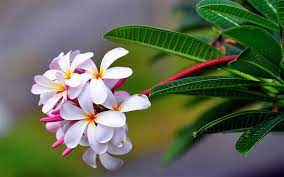

In [5]:
input_image = img.imread('flower.jpg')

print(type(input_image))
input_image

In [5]:
print(input_image)

[[[116 104 106]
  [116 104 106]
  [116 104 106]
  ...
  [ 42 101  43]
  [ 43 100  47]
  [ 43 100  49]]

 [[116 104 106]
  [116 104 106]
  [117 105 107]
  ...
  [  0  54   0]
  [  0  53   0]
  [  0  53   2]]

 [[117 105 107]
  [117 105 107]
  [117 105 107]
  ...
  [  0  60   0]
  [  1  58   5]
  [  1  58   7]]

 ...

 [[ 65 105   9]
  [ 65 105   9]
  [ 64 104   8]
  ...
  [ 10   1  32]
  [ 10   1  32]
  [ 10   1  32]]

 [[ 67 104  11]
  [ 65 104  11]
  [ 66 103   8]
  ...
  [  9   0  29]
  [  9   0  29]
  [  9   0  29]]

 [[ 67 102  12]
  [ 66 102  12]
  [ 67 102  10]
  ...
  [  9   0  27]
  [  9   0  27]
  [  9   0  27]]]


In [6]:
# Normalización
image_array = input_image/255
print(image_array.shape)
image_array

(177, 284, 3)


array([[[0.45490196, 0.40784314, 0.41568627],
        [0.45490196, 0.40784314, 0.41568627],
        [0.45490196, 0.40784314, 0.41568627],
        ...,
        [0.16470588, 0.39607843, 0.16862745],
        [0.16862745, 0.39215686, 0.18431373],
        [0.16862745, 0.39215686, 0.19215686]],

       [[0.45490196, 0.40784314, 0.41568627],
        [0.45490196, 0.40784314, 0.41568627],
        [0.45882353, 0.41176471, 0.41960784],
        ...,
        [0.        , 0.21176471, 0.        ],
        [0.        , 0.20784314, 0.        ],
        [0.        , 0.20784314, 0.00784314]],

       [[0.45882353, 0.41176471, 0.41960784],
        [0.45882353, 0.41176471, 0.41960784],
        [0.45882353, 0.41176471, 0.41960784],
        ...,
        [0.        , 0.23529412, 0.        ],
        [0.00392157, 0.22745098, 0.01960784],
        [0.00392157, 0.22745098, 0.02745098]],

       ...,

       [[0.25490196, 0.41176471, 0.03529412],
        [0.25490196, 0.41176471, 0.03529412],
        [0.25098039, 0

In [7]:
# We represent the image as a one-dimensional vector and return it
def image_to_vector(img_array):
    return np.reshape(a=img_array, newshape=(functools.reduce(operator.mul, img_array.shape)))
# Convert the one-dimensional vector to an array
def vector_to_array(input_vector, shape):
    # Checking whether reshaping is possible
    if len(input_vector) != functools.reduce(operator.mul, shape):
        raise ValueError("Reshaping failed")
    return np.reshape(a=input_vector, newshape=shape)

In [8]:
# Target image after encoding. Value encoding is used.
image_encode = image_to_vector(input_image)
print(image_encode.shape)
image_encode


(150804,)


array([116, 104, 106, ...,   9,   0,  27], dtype=uint8)

In [9]:
# We now calculate the fitness value for a solution from the population.
# The sum of absolute differences between individual genes values gives us the fitness value required.
def fitness_func(ga_instance, solution, solution_idx):
    fitness_value = np.sum(np.abs(image_encode-solution))
    # Negate the fitness value to turn it from decreasing to increasing
    fitness_value = np.sum(image_encode) - fitness_value
    return fitness_value

In [10]:
# Save the output of the run to a new image and enumerate the number of iterations taken
def callback_func(genetic_var):
    if genetic_var.generations_completed % 500 == 0:
        plt.imsave('Final_GA_Image_'+str(genetic_var.generations_completed)+'.png', vector_to_array(genetic_var.best_solution()[0], input_image.shape))


In [11]:
# Initiate the Genetic Algorithm class with the given parameters
genetic_var = pygad.GA(num_generations=20999,
                       num_parents_mating=12,                 # Number of Parent Solutions to consider
                       fitness_func=fitness_func,                  # Choosing which fitness function to use
                       init_range_low=0,                               # Lower scale entry point (Should be integer between 0-1)
                       init_range_high=1,                              # Higher scale exit point  (Should be integer between 0-1)
                       sol_per_pop=22,                                 # Number of populations to work through
                       num_genes=input_image.size,         # Number of genes to use
                       mutation_by_replacement=True,
                       mutation_percent_genes=0.02,        # % of genes from the population that need to be mutated
                       mutation_type="random",                 # Type of mutation
                       on_generation=callback_func,
                       random_mutation_min_val=0,
                       random_mutation_max_val=1,
                       save_solutions=False)        # Mutation minimum and maximum values (range 0-1)


/usr/local/lib/python3.11/dist-packages/pygad/visualize/plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


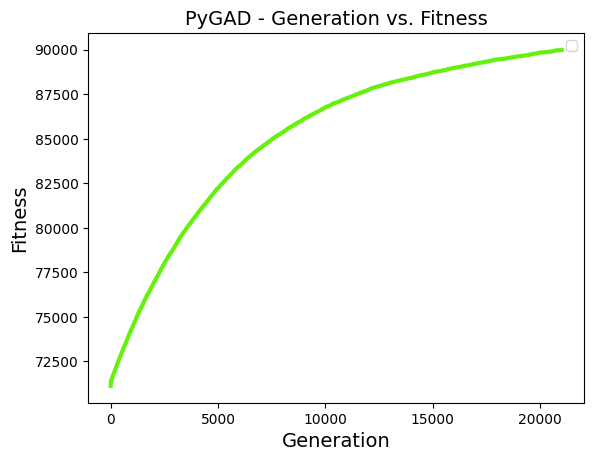

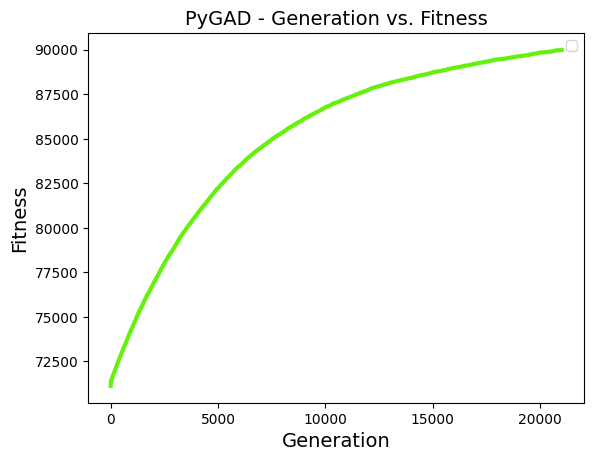

In [12]:
# Run the GA instance: with gen=20999 it takes 1h 58.5 min
genetic_var.run()
# Plot the GA run over time to see how image evolved
genetic_var.plot_fitness()


Selected Solution's Fitness Value = 89991.08851723932
Iteration of the Selected Solution : 0
Selected Solution was reached at the 20993 generation.


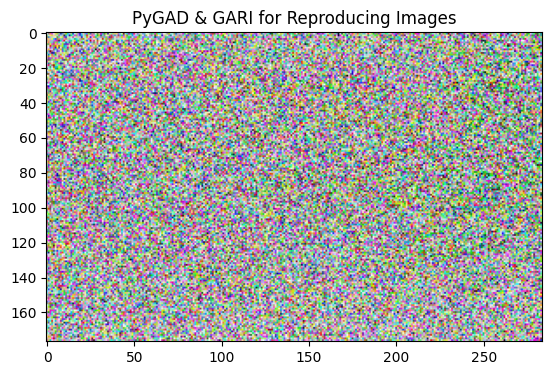

In [13]:
# We will now see some metrics for the best solution
sol, result_fit, idx = genetic_var.best_solution()
print("Selected Solution's Fitness Value = {result_fit}".format(result_fit=result_fit))
print(f"Iteration of the Selected Solution : {idx}")
if genetic_var.best_solution_generation != -1:
    print("Selected Solution was reached at the {best_solution_generation} generation.".format(best_solution_generation=genetic_var.best_solution_generation))
final_result = vector_to_array(sol, input_image.shape)
plt.imshow(final_result)
plt.title("PyGAD & GARI for Reproducing Images")
plt.show()

In [14]:
!ls

Final_GA_Image_10000.png  Final_GA_Image_16500.png  Final_GA_Image_5000.png
Final_GA_Image_1000.png   Final_GA_Image_17000.png  Final_GA_Image_500.png
Final_GA_Image_10500.png  Final_GA_Image_17500.png  Final_GA_Image_5500.png
Final_GA_Image_11000.png  Final_GA_Image_18000.png  Final_GA_Image_6000.png
Final_GA_Image_11500.png  Final_GA_Image_18500.png  Final_GA_Image_6500.png
Final_GA_Image_12000.png  Final_GA_Image_19000.png  Final_GA_Image_7000.png
Final_GA_Image_12500.png  Final_GA_Image_19500.png  Final_GA_Image_7500.png
Final_GA_Image_13000.png  Final_GA_Image_20000.png  Final_GA_Image_8000.png
Final_GA_Image_13500.png  Final_GA_Image_2000.png   Final_GA_Image_8500.png
Final_GA_Image_14000.png  Final_GA_Image_20500.png  Final_GA_Image_9000.png
Final_GA_Image_14500.png  Final_GA_Image_2500.png   Final_GA_Image_9500.png
Final_GA_Image_15000.png  Final_GA_Image_3000.png   flower.jpg
Final_GA_Image_1500.png   Final_GA_Image_3500.png   sample_data
Final_GA_Image_15500.png  Final_GA_Ima

In [20]:
!zip -r /content/file.zip /content/Final*

updating: content/Final_GA_Image_5500.png (deflated 0%)
updating: content/Final_GA_Image_9500.png (deflated 0%)
updating: content/Final_GA_Image_3500.png (deflated 0%)
updating: content/Final_GA_Image_9000.png (deflated 0%)
updating: content/Final_GA_Image_7000.png (deflated 0%)
updating: content/Final_GA_Image_17500.png (deflated 0%)
updating: content/Final_GA_Image_17000.png (deflated 0%)
updating: content/Final_GA_Image_1500.png (deflated 0%)
updating: content/Final_GA_Image_18000.png (deflated 0%)
updating: content/Final_GA_Image_500.png (deflated 0%)
updating: content/Final_GA_Image_10500.png (deflated 0%)
updating: content/Final_GA_Image_8000.png (deflated 0%)
updating: content/Final_GA_Image_10000.png (deflated 0%)
updating: content/Final_GA_Image_14000.png (deflated 0%)
updating: content/Final_GA_Image_1000.png (deflated 0%)
updating: content/Final_GA_Image_19000.png (deflated 0%)
updating: content/Final_GA_Image_11000.png (deflated 0%)
updating: content/Final_GA_Image_2000.png

In [21]:
!ls


file.zip		  Final_GA_Image_16000.png  Final_GA_Image_4500.png
Final_GA_Image_10000.png  Final_GA_Image_16500.png  Final_GA_Image_5000.png
Final_GA_Image_1000.png   Final_GA_Image_17000.png  Final_GA_Image_500.png
Final_GA_Image_10500.png  Final_GA_Image_17500.png  Final_GA_Image_5500.png
Final_GA_Image_11000.png  Final_GA_Image_18000.png  Final_GA_Image_6000.png
Final_GA_Image_11500.png  Final_GA_Image_18500.png  Final_GA_Image_6500.png
Final_GA_Image_12000.png  Final_GA_Image_19000.png  Final_GA_Image_7000.png
Final_GA_Image_12500.png  Final_GA_Image_19500.png  Final_GA_Image_7500.png
Final_GA_Image_13000.png  Final_GA_Image_20000.png  Final_GA_Image_8000.png
Final_GA_Image_13500.png  Final_GA_Image_2000.png   Final_GA_Image_8500.png
Final_GA_Image_14000.png  Final_GA_Image_20500.png  Final_GA_Image_9000.png
Final_GA_Image_14500.png  Final_GA_Image_2500.png   Final_GA_Image_9500.png
Final_GA_Image_15000.png  Final_GA_Image_3000.png   flower.jpg
Final_GA_Image_1500.png   Final_GA_Image

In [22]:
from google.colab import files
files.download("/content/file.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>